# Part 1 — Synthetic Vibration Sensor: data & consistency

This notebook **visualizes the signal** produced by the synthetic sensor
(`fibersail_edge.DampedOscillatorSensor`) and **proves its consistency** — the
properties Parts 2 (edge processing) and 3 (cloud sync) rely on.

The sensor is a noise-driven damped harmonic oscillator

$$x''(t) + 2\,\zeta\,\omega_n\,x'(t) + \omega_n^2\,x(t) = F(t)$$

integrated with a fixed-step RK4, streamed one sample at a time. A **fault**
(bearing wear / loosening mount) is injected for a known window by shifting
$\omega_n$ and/or $\zeta$, giving a **ground-truth anomaly window** to detect.

**What to look for**
1. Time series with the fault window shaded
2. Waveform healthy-vs-fault zoom
3. Power spectral density — the fault moves the resonance peak
4. Rolling RMS over time (a preview of the Part 2 feature)
5. Automated **consistency checks** (constant Δt, finiteness, reproducibility, bounded memory)
6. The provided CSV replayed through the *same* streaming interface

In [1]:
import sys, itertools, tracemalloc
from pathlib import Path

# Locate the repo root (the directory that holds pyproject.toml) so the package
# imports whether the notebook is launched from notebooks/ or the repo root.
# (Under `uv run` the package is already installed in .venv; this src/ fallback
# covers running the notebook outside the uv environment.)
root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
%matplotlib inline

from fibersail_edge import DampedOscillatorSensor, SensorConfig, FaultConfig, CsvReplaySource

# Consistent, colorblind-safe styling (data-viz reference palette, slots 1 & 2).
BLUE, ORANGE, CRIT = "#2a78d6", "#eb6834", "#d03b3b"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "figure.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "legend.frameon": False,
})
CSV_PATH = root / "take_home_exercise" / "sample_dataset_small.csv"

def collect(config):
    "Drain a finite sensor stream into (sensor, t, value) arrays."
    s = DampedOscillatorSensor(config)
    data = np.array([(x.t, x.value) for x in s.stream()])
    return s, data[:, 0], data[:, 1]

print("repo root:", root)

repo root: /home/tiago-portela/Projects/Fibersail


## 1. Generate a 10 s run with an injected fault

We lower the natural frequency (`omega_n_factor=0.7`, bearing-wear-like) **and**
the damping (`zeta_factor=0.4`, a looser, more resonant mount) for a 2-second
window. Both a frequency shift **and** an amplitude change should appear.

In [2]:
FS, FN, FACTOR = 1000.0, 50.0, 0.7
cfg = SensorConfig(
    sample_rate_hz=FS, natural_freq_hz=FN, zeta=0.05, channel="acceleration",
    duration_s=10.0, seed=42,
    fault=FaultConfig(start_s=4.0, duration_s=2.0, omega_n_factor=FACTOR, zeta_factor=0.4),
)
sensor, t, x = collect(cfg)
f0, f1 = sensor.fault_window
print(f"{len(x):,} samples @ {FS:.0f} Hz over {t[-1]:.2f} s")
print(f"ground-truth fault window = [{f0:.1f}, {f1:.1f}] s "
      f"(f_n {FN:.0f} Hz -> {FN*FACTOR:.0f} Hz during fault)")

10,000 samples @ 1000 Hz over 10.00 s
ground-truth fault window = [4.0, 6.0] s (f_n 50 Hz -> 35 Hz during fault)


## 2. Time series with the fault window shaded

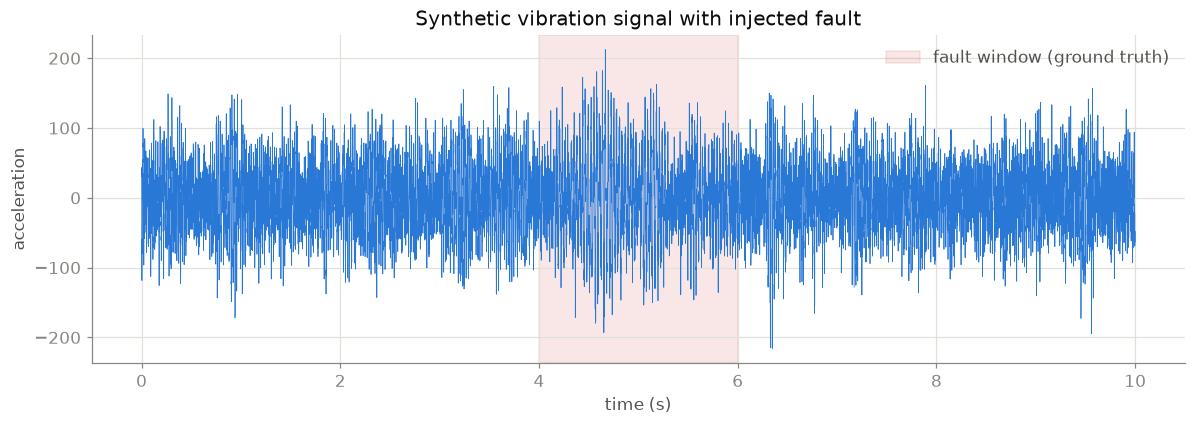

In [3]:
fig, ax = plt.subplots()
ax.plot(t, x, color=BLUE, lw=0.5)
ax.axvspan(f0, f1, color=CRIT, alpha=0.12, label="fault window (ground truth)")
ax.set(xlabel="time (s)", ylabel="acceleration",
       title="Synthetic vibration signal with injected fault")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 3. Waveform: healthy vs fault (200 ms zoom)

Same time span in each trace — the fault trace visibly oscillates slower (lower
frequency) and larger (less damping).

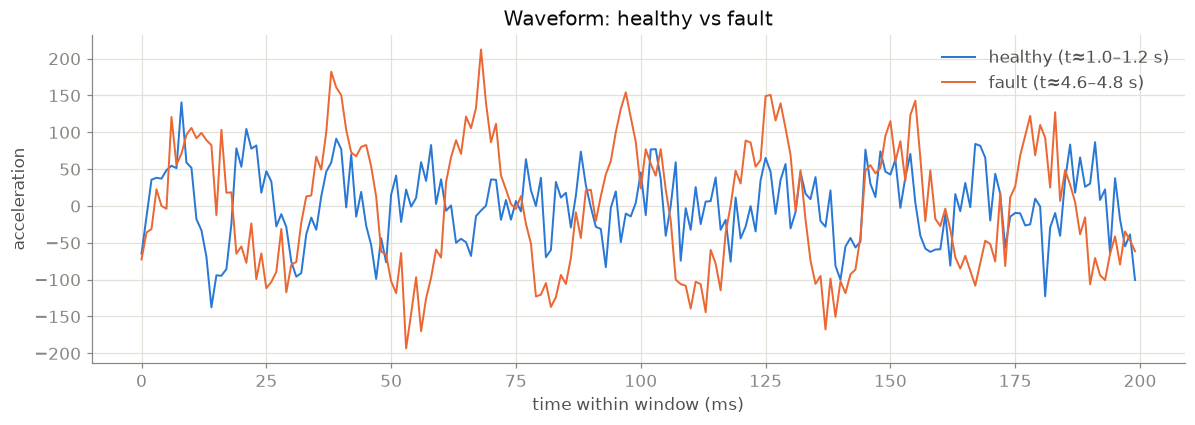

In [4]:
def window(a, b):
    m = (t >= a) & (t < b)
    return t[m] - a, x[m]

th, xh = window(1.0, 1.2)
tf, xf = window(4.6, 4.8)
fig, ax = plt.subplots()
ax.plot(th * 1e3, xh, color=BLUE, lw=1.3, label="healthy (t≈1.0–1.2 s)")
ax.plot(tf * 1e3, xf, color=ORANGE, lw=1.3, label="fault (t≈4.6–4.8 s)")
ax.set(xlabel="time within window (ms)", ylabel="acceleration",
       title="Waveform: healthy vs fault")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 4. Power spectral density — the fault moves the resonance peak

Welch PSD of a healthy segment vs a fault segment (no look-ahead — each uses only
its own samples). The dominant peak slides from $f_n$ toward $f_n\times$factor,
which is exactly what the Part 2 dominant-frequency feature will track.

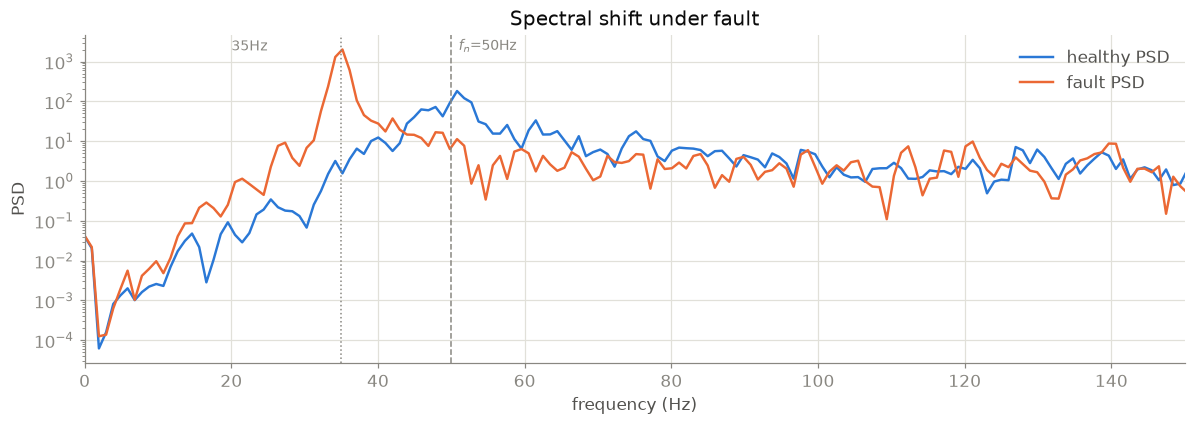

In [5]:
def seg(a, b):
    m = (t >= a) & (t < b)
    return x[m]

fh, Ph = welch(seg(1.0, 3.5), fs=FS, nperseg=1024)
ff, Pf = welch(seg(4.1, 5.9), fs=FS, nperseg=1024)
fig, ax = plt.subplots()
ax.semilogy(fh, Ph, color=BLUE, lw=1.6, label="healthy PSD")
ax.semilogy(ff, Pf, color=ORANGE, lw=1.6, label="fault PSD")
ax.axvline(FN, color=MUTED, ls="--", lw=1)
ax.axvline(FN * FACTOR, color=MUTED, ls=":", lw=1)
ax.text(FN + 1, ax.get_ylim()[1] * 0.4, f"$f_n$={FN:.0f}Hz", color=MUTED, fontsize=9)
ax.text(FN * FACTOR - 15, ax.get_ylim()[1] * 0.4, f"{FN*FACTOR:.0f}Hz", color=MUTED, fontsize=9)
ax.set(xlim=(0, 150), xlabel="frequency (Hz)", ylabel="PSD",
       title="Spectral shift under fault")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 5. Rolling RMS over time (Part 2 feature preview)

A causal 250 ms rolling RMS (value at time $i$ uses only samples up to $i$).
The energy rises inside the fault window — the basis for a simple threshold
detector in Part 2.

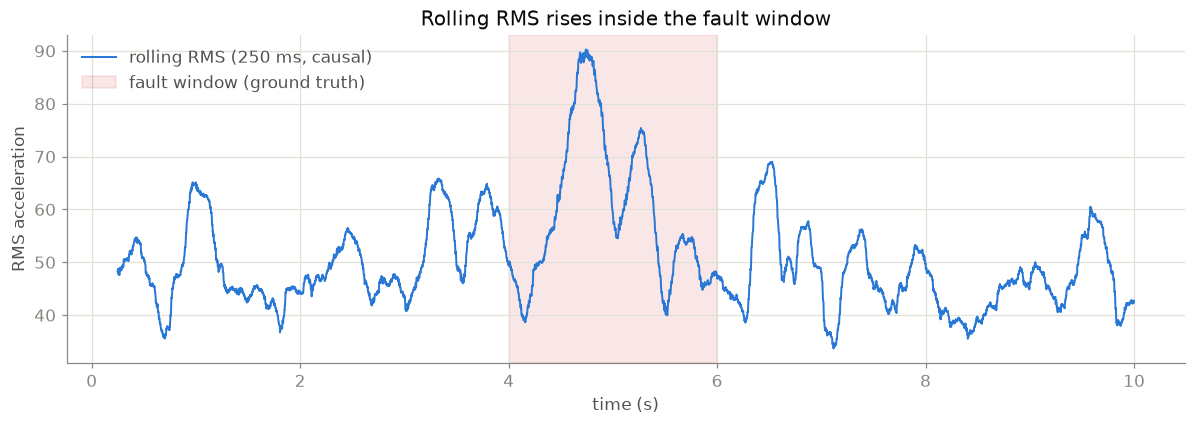

In [6]:
win = int(0.25 * FS)                      # 250 ms causal window
csum = np.cumsum(np.insert(x ** 2, 0, 0.0))
rms = np.sqrt((csum[win:] - csum[:-win]) / win)
t_rms = t[win - 1:]

fig, ax = plt.subplots()
ax.plot(t_rms, rms, color=BLUE, lw=1.3, label="rolling RMS (250 ms, causal)")
ax.axvspan(f0, f1, color=CRIT, alpha=0.12, label="fault window (ground truth)")
ax.set(xlabel="time (s)", ylabel="RMS acceleration",
       title="Rolling RMS rises inside the fault window")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 6. Consistency checks (automated)

Machine-checked properties the downstream services depend on. Every row must PASS.

In [7]:
checks = []

dt = np.diff(t)
checks.append(("constant sampling interval Δt", bool(np.allclose(dt, 1 / FS)),
               f"Δt std = {dt.std():.2e} s"))

checks.append(("all samples finite (no NaN/Inf)", bool(np.all(np.isfinite(x))), ""))

a = np.fromiter((s.value for s in DampedOscillatorSensor(SensorConfig(duration_s=0.5, seed=1)).stream()), float)
b = np.fromiter((s.value for s in DampedOscillatorSensor(SensorConfig(duration_s=0.5, seed=1)).stream()), float)
c = np.fromiter((s.value for s in DampedOscillatorSensor(SensorConfig(duration_s=0.5, seed=2)).stream()), float)
checks.append(("reproducible for a fixed seed", bool(np.array_equal(a, b)), f"max|Δ| = {np.max(np.abs(a-b)):.1e}"))
checks.append(("different seed -> different signal", bool(not np.array_equal(a, c)), ""))

n = sum(1 for _ in DampedOscillatorSensor(SensorConfig(duration_s=1.0, sample_rate_hz=FS)).stream())
checks.append(("sample count == fs × duration", n == int(FS), f"n = {n}"))

def peak_bytes(nsamp):
    stream = DampedOscillatorSensor(SensorConfig(duration_s=None)).stream()
    tracemalloc.start()
    acc = 0.0
    for s in itertools.islice(stream, nsamp):
        acc += s.value                    # consume without storing
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak

p1, p10 = peak_bytes(5_000), peak_bytes(50_000)
checks.append(("memory bounded (10× samples ≈ same peak)", p10 < p1 + 200_000,
               f"{p1:,} -> {p10:,} bytes for 5k -> 50k samples"))

width = max(len(name) for name, _, _ in checks)
for name, ok, detail in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name:<{width}}   {detail}")
assert all(ok for _, ok, _ in checks), "a consistency check failed"
print("\nAll consistency checks passed.")

[PASS] constant sampling interval Δt              Δt std = 4.67e-16 s
[PASS] all samples finite (no NaN/Inf)            
[PASS] reproducible for a fixed seed              max|Δ| = 0.0e+00
[PASS] different seed -> different signal         
[PASS] sample count == fs × duration              n = 1000
[PASS] memory bounded (10× samples ≈ same peak)   1,840 -> 1,840 bytes for 5k -> 50k samples

All consistency checks passed.


## 7. The provided dataset through the *same* interface

`CsvReplaySource` replays `sample_dataset_small.csv` behind the identical
`SampleSource` contract, so Parts 2 & 3 don't care whether data is synthetic or
recorded. Strain and temperature are shown as separate panels (never a shared /
dual axis).

sample_rate ≈ 90.9 Hz   fault_window = None
1,818 populated rows (blank filler rows skipped)


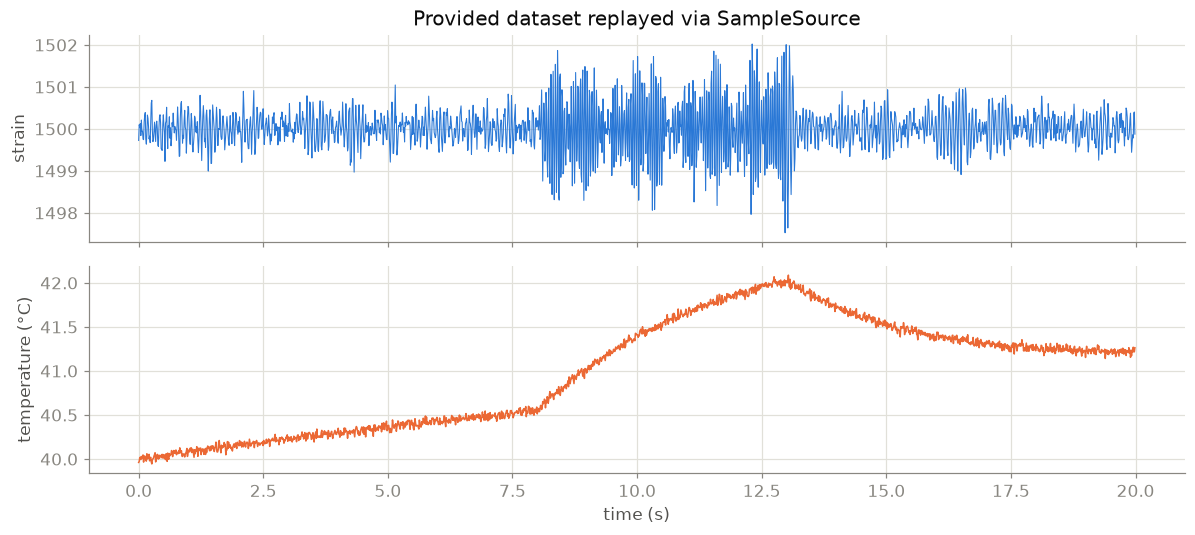

In [8]:
csv = CsvReplaySource(str(CSV_PATH))
print("sample_rate ≈", round(csv.sample_rate_hz, 1), "Hz   fault_window =", csv.fault_window)

rows = list(csv.stream_full())
tc = np.array([r[0] for r in rows])
strain = np.array([r[1] for r in rows])
temp = np.array([np.nan if r[2] is None else r[2] for r in rows])
print(f"{len(rows):,} populated rows (blank filler rows skipped)")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(11, 5))
ax1.plot(tc, strain, color=BLUE, lw=0.7)
ax1.set(ylabel="strain", title="Provided dataset replayed via SampleSource")
ax2.plot(tc, temp, color=ORANGE, lw=1.0)
ax2.set(xlabel="time (s)", ylabel="temperature (°C)")
plt.tight_layout(); plt.show()

## Assumptions & notes

* **Forcing $F(t)$** is drawn once per integration step (piecewise-constant,
  band-limited noise). A literally white-noise-driven ODE is an SDE for which RK4
  is not formally convergent; holding the force constant over a step is both
  physically reasonable (real excitation is band-limited) and numerically sound.
* **Noise scaling** uses per-step std $=\texttt{force\_std}\cdot\sqrt{f_s}$, so the
  excitation PSD — and thus the physical response — is invariant to sample rate.
* **Warmup**: the integrator runs for `warmup_s` before $t=0$ so the emitted
  signal is already stationary at the first sample.
* **Ground truth** (`fault_window`) is metadata only; it never enters `stream()`,
  so a detector cannot peek at labels.
* **CSV replay** treats a row as a sample only when `strain` is present and skips
  the blank filler rows (no forward-fill, which would fabricate spectral content).